# `date_recorded` 01: basic `date` breakdown

**Purpose:** apply the analysis that is always performed for this feature
type, without mixing in cross-feature interpretation.

**Current role:** `candidate`

**Provisional disposition:** derive recording year and month


## Standard checks for `date`

        Every predictor with this audit type receives the same basic checks:

        - strict parsing and invalid values
- minimum, maximum and unique dates
- year/month survey-wave coverage
- training/test calendar stability

        This notebook stays descriptive. Target interpretation belongs in notebook 02,
        and cross-feature relationships belong in notebook 03.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_stage_directory():
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (
            (candidate / "data" / "TrainingSetValues.csv").exists()
            and (candidate / "src" / "source_data_validation.py").exists()
        ):
            return candidate
    raise FileNotFoundError("Could not locate the stage-1-pump-it-up directory.")


stage_directory = find_stage_directory()
source_directory = str((stage_directory / "src").resolve())
if source_directory not in sys.path:
    sys.path.insert(0, source_directory)

from predictor_audit import (
    analysis_categories,
    categorical_summary,
    categorical_target_profile,
    category_frequency_table,
    numeric_summary,
    numeric_target_summary,
    related_feature_summary,
    sentinel_mask,
    source_blank_mask,
    text_normalisation_summary,
)
from source_data_validation import (
    validate_aligned_ids,
    validate_label_frame,
    validate_raw_feature_schema,
)

data_directory = stage_directory / "data"
training_features = pd.read_csv(
    data_directory / "TrainingSetValues.csv",
    keep_default_na=False,
)
training_labels = pd.read_csv(
    data_directory / "TrainingSetLabels.csv",
    keep_default_na=False,
)
test_features = pd.read_csv(
    data_directory / "TestSetValues.csv",
    keep_default_na=False,
)

validate_raw_feature_schema(training_features)
validate_raw_feature_schema(test_features)
validate_label_frame(training_labels)
validate_aligned_ids(training_features, training_labels)

training_data = training_features.merge(
    training_labels,
    on="id",
    validate="one_to_one",
)

feature = 'date_recorded'
feature_metadata = {'order': 2, 'name': 'date_recorded', 'audit_type': 'date', 'role': 'candidate', 'disposition': 'derive recording year and month', 'finding': 'Every supplied date parses, but collection timing is concentrated in survey waves.', 'decision': 'Derive stable calendar components and avoid one-hot encoding every raw date.', 'risk': 'Recording time can proxy survey operations and geography rather than waterpoint condition.', 'related': [{'feature': 'construction_year', 'reason': 'Together they define waterpoint age at observation.'}, {'feature': 'region', 'reason': 'Survey waves may have moved through regions at different times.'}, {'feature': 'installer', 'reason': 'Installer activity and recorded construction cohorts may be time-dependent.'}]}
feature_types = {'amount_tsh': 'numeric', 'date_recorded': 'date', 'funder': 'high-cardinality-category', 'gps_height': 'numeric', 'installer': 'high-cardinality-category', 'longitude': 'coordinate', 'latitude': 'coordinate', 'wpt_name': 'high-cardinality-category', 'num_private': 'numeric', 'basin': 'category', 'subvillage': 'high-cardinality-category', 'region': 'category', 'region_code': 'category', 'district_code': 'category', 'lga': 'category', 'ward': 'high-cardinality-category', 'population': 'numeric', 'public_meeting': 'binary', 'recorded_by': 'constant', 'scheme_management': 'category', 'scheme_name': 'high-cardinality-category', 'permit': 'binary', 'construction_year': 'year', 'extraction_type': 'category', 'extraction_type_group': 'category', 'extraction_type_class': 'category', 'management': 'category', 'management_group': 'category', 'payment': 'category', 'payment_type': 'category', 'water_quality': 'category', 'quality_group': 'category', 'quantity': 'category', 'quantity_group': 'category', 'source': 'category', 'source_type': 'category', 'source_class': 'category', 'waterpoint_type': 'category', 'waterpoint_type_group': 'category'}
assert feature in training_features.columns
print(
    f"Validated {len(training_features):,} training rows and "
    f"{len(test_features):,} test rows for {feature}."
)


Validated 59,400 training rows and 14,850 test rows for date_recorded.


## Parsing and calendar coverage


,rows,invalid or missing,minimum,maximum,unique dates,years
training,59400,0,2002-10-14,2013-12-03,356,5
test,14850,0,2001-03-26,2013-12-03,331,5


,training (%),test (%)
date_recorded,,
1,10.70,10.43
2,20.88,20.73
3,30.20,30.22
4,6.68,6.77
5,0.57,0.45
6,0.58,0.79
7,11.66,11.69
8,5.66,5.50
9,0.55,0.44


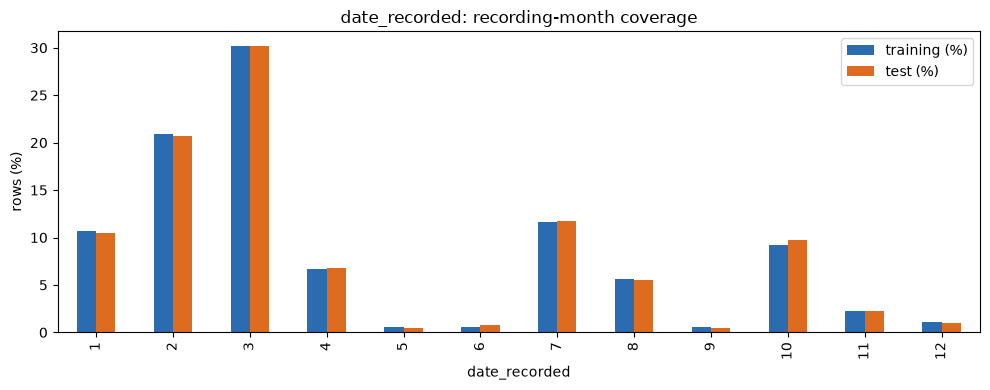

In [2]:
training_dates = pd.to_datetime(training_features[feature], errors="coerce")
test_dates = pd.to_datetime(test_features[feature], errors="coerce")
date_summary = pd.DataFrame({
    "rows": [len(training_dates), len(test_dates)],
    "invalid or missing": [training_dates.isna().sum(), test_dates.isna().sum()],
    "minimum": [training_dates.min(), test_dates.min()],
    "maximum": [training_dates.max(), test_dates.max()],
    "unique dates": [training_dates.nunique(), test_dates.nunique()],
    "years": [training_dates.dt.year.nunique(), test_dates.dt.year.nunique()],
}, index=["training", "test"])
display(date_summary)

month_share = pd.DataFrame({
    "training (%)": training_dates.dt.month.value_counts(normalize=True).sort_index() * 100,
    "test (%)": test_dates.dt.month.value_counts(normalize=True).sort_index() * 100,
}).fillna(0).round(2)
display(month_share)
month_share.plot(kind="bar", figsize=(10, 4), color=["#2b6cb0", "#dd6b20"])
plt.ylabel("rows (%)")
plt.title(f"{feature}: recording-month coverage")
plt.tight_layout()
plt.show()


## Basic-breakdown handoff

The outputs above establish shape, missingness, support and supplied
train/test coverage. They do not by themselves establish usefulness or a
causal explanation. Notebook 02 interprets noteworthy single-feature
evidence; notebook 03 tests the explicitly related predictors.
